In [1]:
"""
This script loads in responses from classification csv file output by Zooniverse,
and normalizes them into a table with one row per task answered
"""
import logging
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from analysis_helpers import load_raw, wrap_labels

# PARAMETERS
base_dir = Path(r"Y:\projects\unep-life-cycle-assessment-ml-paper-evaluation")

classifications_csv_path = base_dir / '4_survey_responses'/'may-survey-classifications_2025-06-17.csv'
output_dir = base_dir / '5_analysis'/'analysis'
ml_responses_database_path = base_dir / '2_retrieved_responses' / 'records_bedrock.db'
subjects_path = base_dir / '4_survey_responses'/'review-llm-responses-on-lca-tasks-subjects.csv'
prompts_database_path = base_dir / '1_input_prompts' / 'prompts.json'
workflow_id = 28845

exclude_prompts = [17]
exclude_models=['ollama_chat/deepseek-r1:8b'] # Deepseek-r1 was run with two inference platforms. We retain the results for the deepseek model with more parameters for a fair comparison

In [2]:

sns.set_theme(style="darkgrid")


# Load data

In [3]:
current_date = datetime.now().strftime('%Y%m%d')

logging.basicConfig(level=logging.INFO)

# Read classifications
classifications_df = pd.read_csv(classifications_csv_path)
output_dir = Path(output_dir)
output_dir.mkdir(parents=True, exist_ok=True)


In [4]:
combined_final = load_raw(classifications_csv_path, subjects_path, prompts_database_path, workflow_id,exclude_prompt_ids=exclude_prompts,exclude_models=exclude_models)

In [5]:
summary_q2 = combined_final.T2.value_counts()

In [6]:
summary_q2

T2
3 - good                          77
2 - average                       46
1 - poor                          28
4 - expert / better than human    17
Name: count, dtype: int64

In [7]:
# map t2 to numerical values
rating_description_to_number = {"3 - good": 3,
"2 - average": 2,
"1 - poor": 1,
"4 - expert / better than human": 4}

In [8]:
combined_final['T2_score']=combined_final['T2'].apply(lambda x: rating_description_to_number[x])

In [9]:
combined_final.columns

Index(['original_index', 'T1', 'T10', 'T11', 'T12', 'T2', 'T3', 'T4', 'T6',
       'T7', 'T8', 'T9', 'subject_id', 'project_id', 'workflow_id',
       'subject_set_id', 'metadata', 'locations', 'classifications_count',
       'retired_at', 'retirement_reason', 'created_at', 'updated_at',
       '#date_run', 'prompt_id', '#llm_model', 'response_id', '#temperature',
       '#llm_provider', '#prompt_run_by', 'prompt_text', 'T2_score',
       'T3_score', 'T4_score', 'T12_score', 'count_citations'],
      dtype='object')

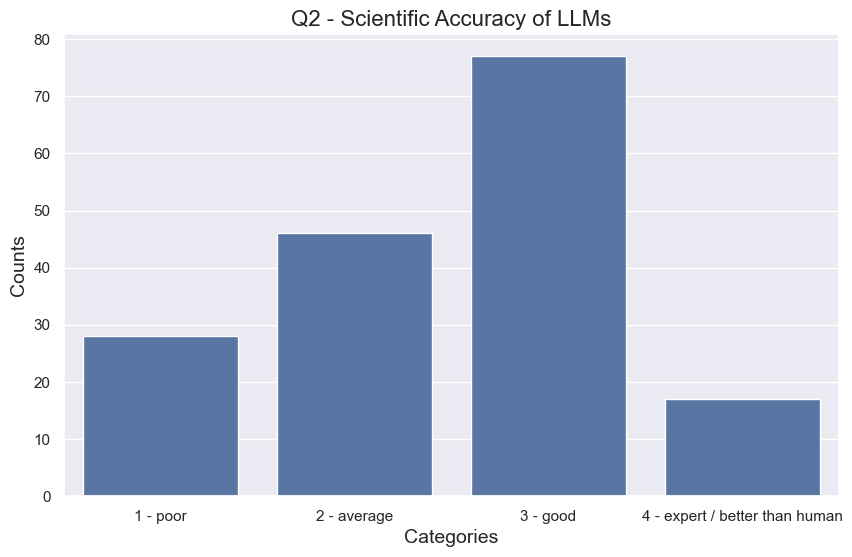

In [10]:


# Bar Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=summary_q2.index, y=summary_q2.values,order=summary_q2.index.sort_values())
plt.title('Q2 - Scientific Accuracy of LLMs',fontsize=16)
plt.xlabel('Categories',fontsize=14)
plt.ylabel('Counts',fontsize=14)
plt.show()

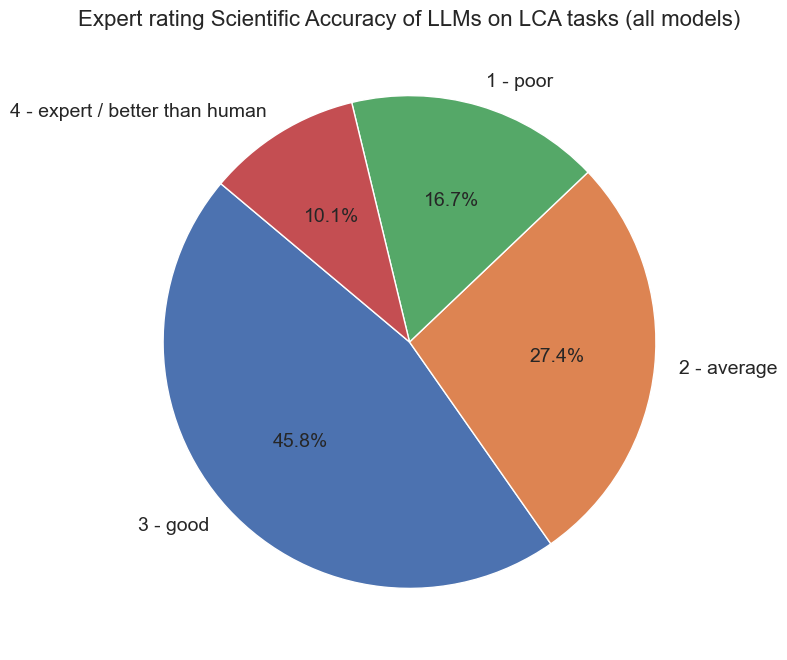

In [11]:
# Pie Chart with larger text
plt.figure(figsize=(8, 8))
plt.pie(summary_q2.values, labels=summary_q2.index, autopct='%1.1f%%', startangle=140, textprops={'fontsize': 14})
plt.title('Expert rating Scientific Accuracy of LLMs on LCA tasks (all models)', fontsize=16)
plt.show()

In [12]:
q2_by_model = combined_final.groupby(['#llm_model', 'T2_score']).size().unstack(fill_value=0)

In [13]:
q2_by_model

T2_score,1,2,3,4
#llm_model,,,,
claude-3.7-sonnet,4,4,8,0
deepseek-r1,4,5,6,1
gemini-2.0-flash,1,4,3,4
google-gemma3,3,2,4,0
llama4-maverick,5,3,5,3
llama4-scout,0,3,9,0
microsoft-phi4,3,4,9,0
mistral-large,3,5,8,0
nova-premier-v1,2,5,7,2


In [14]:
model_t2_mean = combined_final.groupby('#llm_model')['T2_score'].mean().sort_values(ascending=False)
print(model_t2_mean)


#llm_model
gemini-2.0-flash     2.833333
openai-gpt-4.1       2.809524
llama4-scout         2.750000
qwen3                2.666667
nova-premier-v1      2.562500
llama4-maverick      2.375000
microsoft-phi4       2.375000
mistral-large        2.312500
claude-3.7-sonnet    2.250000
deepseek-r1          2.250000
google-gemma3        2.111111
Name: T2_score, dtype: float64


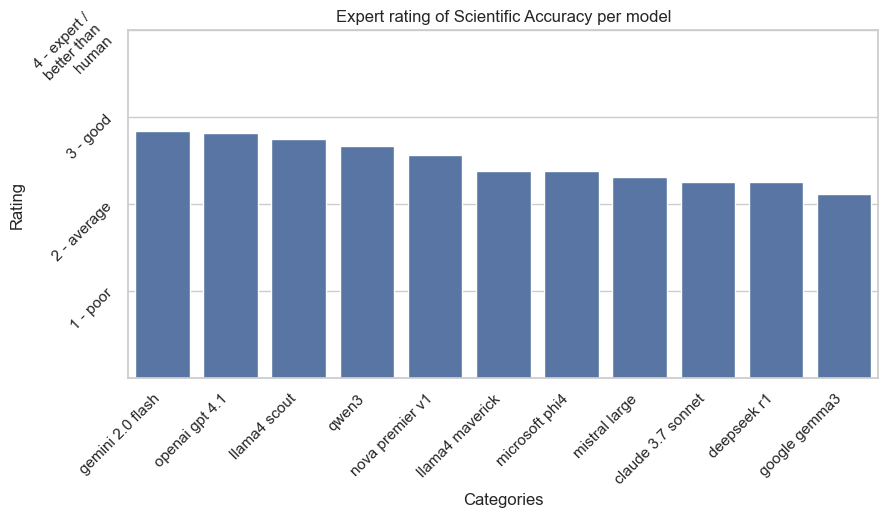

In [15]:
# Count Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=model_t2_mean.index,y=model_t2_mean.values)
plt.title('Expert rating of Scientific Accuracy per model')
plt.xlabel('Categories')
plt.ylabel('Rating')
plt.yticks(list(rating_description_to_number.values()), list(rating_description_to_number.keys()))


plt.subplots_adjust(left=0.15, bottom=0.3)
wrap_labels(plt.gca(), width=15)

plt.savefig(output_dir/f'{current_date}_q2_scientific_accuracy_per_model.png')
plt.show()



In [16]:
model_t2_mean

#llm_model
gemini-2.0-flash     2.833333
openai-gpt-4.1       2.809524
llama4-scout         2.750000
qwen3                2.666667
nova-premier-v1      2.562500
llama4-maverick      2.375000
microsoft-phi4       2.375000
mistral-large        2.312500
claude-3.7-sonnet    2.250000
deepseek-r1          2.250000
google-gemma3        2.111111
Name: T2_score, dtype: float64

Per-model stats with params (first rows):
         llm_model  params_b  T2_score
1      deepseek-r1     671.0  2.250000
3    google-gemma3      27.0  2.111111
4  llama4-maverick     400.0  2.375000
5     llama4-scout     109.0  2.750000
6   microsoft-phi4       4.0  2.375000
Per-model Pearson r=-0.146, p=0.782
Per-model Spearman rho=-0.145, p=0.784


KeyError: 'n'

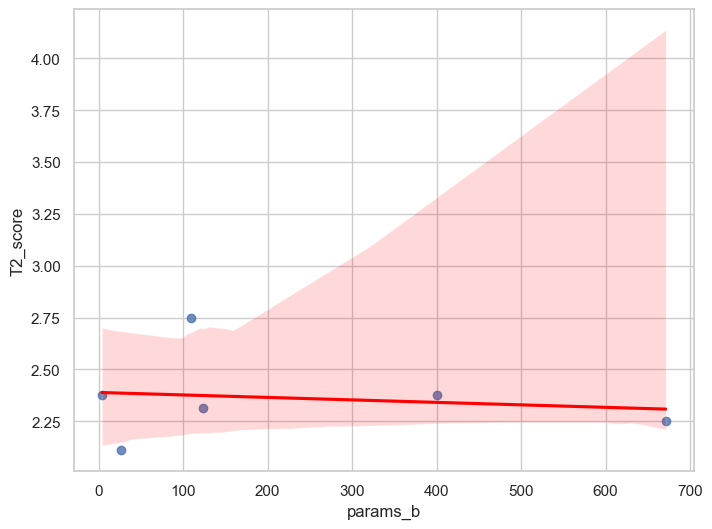

In [17]:

from scipy import stats

# Create a mapping from model name to parameter count in billions (float)
# Attempt to parse from the model string (e.g., ':8b', '27b', '70b', '330b'). Case-insensitive.
# Load the CSV data
params_per_llm = pd.read_csv('param_count.csv')
model_stats = params_per_llm.merge(model_t2_mean,left_on='llm_model',right_on='#llm_model').dropna()


# Drop models without known parameter counts
model_stats_known = model_stats.dropna(subset=['params_b']).copy()

print('Per-model stats with params (first rows):')
print(model_stats_known.head())

# Compute correlations (per-model)
pearson_r, pearson_p = stats.pearsonr(model_stats_known['params_b'], model_stats_known['T2_score']) if len(model_stats_known) > 1 else (float('nan'), float('nan'))
spearman_rho, spearman_p = stats.spearmanr(model_stats_known['params_b'], model_stats_known['T2_score']) if len(model_stats_known) > 1 else (float('nan'), float('nan'))

print(f'Per-model Pearson r={pearson_r:.3f}, p={pearson_p:.3g}')
print(f'Per-model Spearman rho={spearman_rho:.3f}, p={spearman_p:.3g}')

# Scatter with regression line; point size by n
plt.figure(figsize=(8,6))
ax = sns.regplot(data=model_stats_known, x='params_b', y='T2_score', scatter=True, ci=95, line_kws={'color':'red'})
# Scale point sizes: base 50 + 5 per datapoint (cap for readability)
sizes = (50 + model_stats_known['n'].clip(upper=100) * 5).values
plt.scatter(model_stats_known['params_b'], model_stats_known['T2_score'], s=sizes, alpha=0.6, color='C0')

# Annotate each point with model short name (last path segment)
for _, row in model_stats_known.iterrows():
    short = row['#llm_model'].split('/')[-1]
    plt.annotate(short, (row['params_b'], row['T2_score']), textcoords='offset points', xytext=(5,5), fontsize=9)

plt.title(f'q2: Mean explanation score vs model params (per model)\nPearson r={pearson_r:.2f} (p={pearson_p:.2g}), Spearman rho={spearman_rho:.2f} (p={spearman_p:.2g})')
plt.xlabel('Parameters (Billions)')
plt.ylabel('Mean q2 score')
plt.ylim(0.8, 4.2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig(output_dir / f'{current_date}_q2_params_vs_mean_score_per_model.png', dpi=200)
plt.show()


# The same, but take the median

In [22]:
model_t2_median = combined_final.groupby('#llm_model')['T2_score'].median().sort_values(ascending=False)
print(model_t2_mean)


#llm_model
gemini-2.0-flash     2.833333
openai-gpt-4.1       2.809524
llama4-scout         2.750000
qwen3                2.666667
nova-premier-v1      2.562500
llama4-maverick      2.375000
microsoft-phi4       2.375000
mistral-large        2.312500
claude-3.7-sonnet    2.250000
deepseek-r1          2.250000
google-gemma3        2.111111
Name: T2_score, dtype: float64


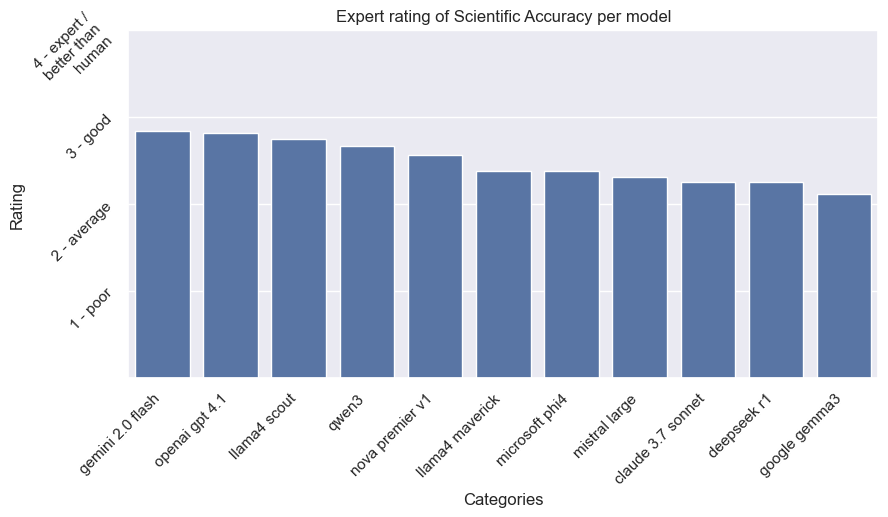

In [23]:

sns.set_theme(style="darkgrid")

# Count Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=model_t2_mean.index,y=model_t2_mean.values)
plt.title('Expert rating of Scientific Accuracy per model')
plt.xlabel('Categories')
plt.ylabel('Rating')
plt.yticks(list(rating_description_to_number.values()), list(rating_description_to_number.keys()))


plt.subplots_adjust(left=0.15, bottom=0.3)
wrap_labels(plt.gca(), width=15)

plt.savefig(output_dir/f'{current_date}_q2_scientific_accuracy_per_model_median.png')
plt.show()



# Violin plot

In [20]:
# Add count of datapoints per model to combined_df
counts_per_model = combined_final.groupby('#llm_model').T2.agg(len).to_dict()

combined_final['data_points_per_model'] = combined_final['#llm_model'].apply(lambda x: counts_per_model[x])

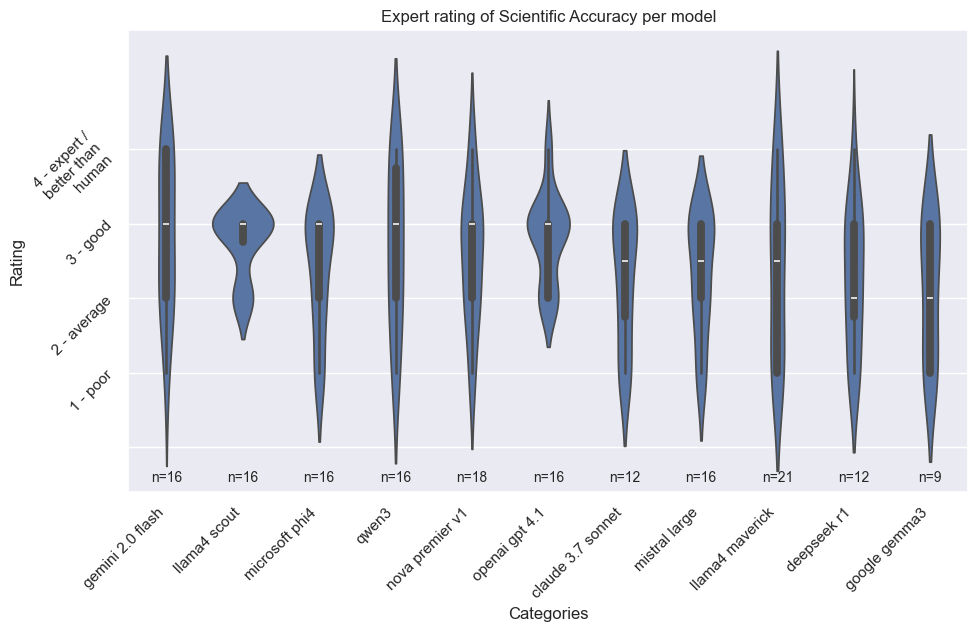

In [23]:
import numpy as np

def convert_dict_to_sorted_list(input_dict):
    # Sort the keys based on their values
    sorted_keys = sorted(input_dict, key=input_dict.get)
    return sorted_keys
ylabels_text = convert_dict_to_sorted_list(rating_description_to_number)
ylabels_text.insert(0,'')
# Violin Plot

plt.figure(figsize=(12, 6))

colors = sns.color_palette("light:#5A9", as_cmap=True)

ax = sns.violinplot(x='#llm_model', y='T2_score', data=combined_final,order=list(model_t2_median.index))
plt.title('Expert rating of Scientific Accuracy per model')
plt.xlabel('Categories')
plt.ylabel('Rating')
plt.yticks(np.arange(0,5,1), ylabels_text)

# Rotate x-tick labels and adjust alignment
plt.xticks(rotation=45, ha='right')
wrap_labels(plt.gca(), width=15)


# Add number of data points to each bar
for i, llm_name in enumerate(combined_final['#llm_model'].unique()):
    count = combined_final[combined_final['#llm_model'] == llm_name]['T2_score'].count()
    ax.text(i, ax.get_ylim()[0] + 0.1, f'n={count}', ha='center', va='bottom', fontsize=10)

plt.subplots_adjust(left=0.15, right=0.85)
plt.savefig(output_dir/f'{current_date}_q2_scientific_accuracy_per_model_violin.png')

plt.show()

C:\Users\Artur\Documents\Projects (local)\GLAD AI\llm testing\Zooniverse project\.venv\lib\site-packages\seaborn\categorical.py:3399: UserWarning: 19.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


AttributeError: 'NoneType' object has no attribute 'remove'

C:\Users\Artur\Documents\Projects (local)\GLAD AI\llm testing\Zooniverse project\.venv\lib\site-packages\seaborn\categorical.py:3399: UserWarning: 19.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


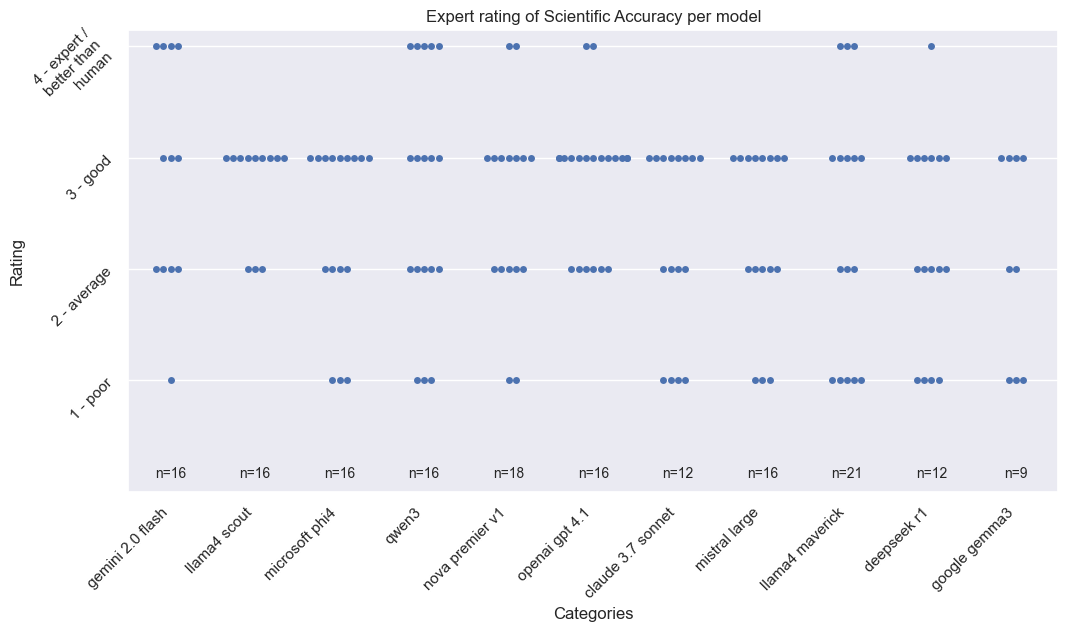

In [22]:
import numpy as np

def convert_dict_to_sorted_list(input_dict):
    # Sort the keys based on their values
    sorted_keys = sorted(input_dict, key=input_dict.get)
    return sorted_keys
ylabels_text = convert_dict_to_sorted_list(rating_description_to_number)
ylabels_text.insert(0,'')
# Violin Plot

plt.figure(figsize=(12, 6))

colors = sns.color_palette("light:#5A9", as_cmap=True)

ax = sns.swarmplot(x='#llm_model', y='T2_score', data=combined_final,order=list(model_t2_median.index))
plt.title('Expert rating of Scientific Accuracy per model')
plt.xlabel('Categories')
plt.ylabel('Rating')
plt.yticks(np.arange(0,5,1), ylabels_text)

# Rotate x-tick labels and adjust alignment
plt.xticks(rotation=45, ha='right')
wrap_labels(plt.gca(), width=15)


# Add number of data points to each bar
for i, llm_name in enumerate(combined_final['#llm_model'].unique()):
    count = combined_final[combined_final['#llm_model'] == llm_name]['T2_score'].count()
    ax.text(i, ax.get_ylim()[0] + 0.1, f'n={count}', ha='center', va='bottom', fontsize=10)

ax.get_legend().remove()
plt.subplots_adjust(left=0.15, right=0.85)
plt.savefig(output_dir/f'{current_date}_q2_scientific_accuracy_per_model_violin.png')

plt.show()

AttributeError: 'NoneType' object has no attribute 'remove'

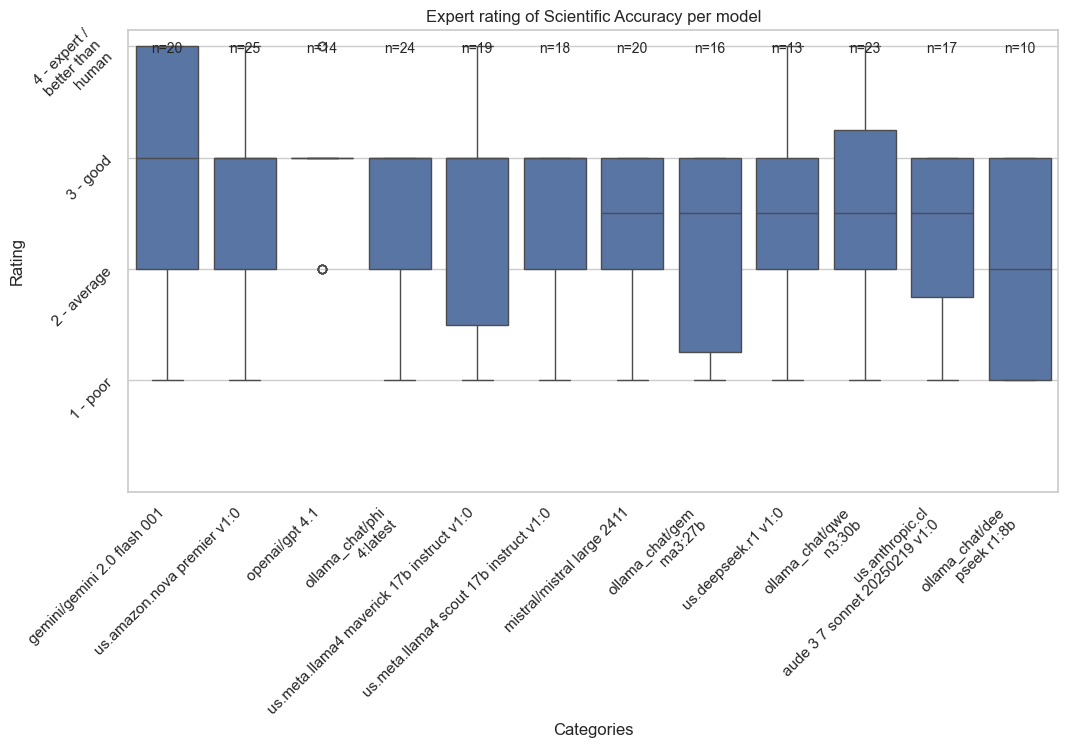

In [49]:
import numpy as np

def convert_dict_to_sorted_list(input_dict):
    # Sort the keys based on their values
    sorted_keys = sorted(input_dict, key=input_dict.get)
    return sorted_keys

ylabels_text = convert_dict_to_sorted_list(rating_description_to_number)
ylabels_text.insert(0, '')

# Whisker Plot
plt.figure(figsize=(12, 6))

colors = sns.color_palette("light:#5A9", as_cmap=True)

ax = sns.boxplot(x='#llm_model', y='T2_score', data=combined_final, order=list(model_t2_median.index))
plt.title('Expert rating of Scientific Accuracy per model')
plt.xlabel('Categories')
plt.ylabel('Rating')
plt.yticks(np.arange(0, 5, 1), ylabels_text)

# Rotate x-tick labels and adjust alignment
plt.xticks(rotation=45, ha='right')
wrap_labels(plt.gca(), width=15)

# Add number of data points to each bar
for i, llm_name in enumerate(combined_final['#llm_model'].unique()):
    count = combined_final[combined_final['#llm_model'] == llm_name]['T2_score'].count()
    ax.text(i, ax.get_ylim()[1] - 0.1, f'n={count}', ha='center', va='top', fontsize=10)

ax.get_legend().remove()
plt.subplots_adjust(left=0.15, right=0.85)
plt.savefig(output_dir / f'{current_date}_q2_scientific_accuracy_per_model_whisker.png')

plt.show()

# Analyze comments on Q2

In [18]:
combined_final.T7.drop_duplicates()

0                   Correct answer, and good explanation
1                                                       
2      response is accurate, but a notice that the pr...
3      Some claims and numbers are wrong and not supp...
4      Generally correct, but misses information on t...
5      LCA is not designed to enylze impacts from pop...
6      Good response, but misses some detail on the +...
7      misses the allocation hierachy and reference t...
8      The answer is properly drafted. It is a pity i...
9      The answer does not refer to iso norms. This m...
10     th answer reports some citations which are not...
11     All the inputs are taken into account and rele...
12     The answer does not quote references and iso n...
13     There is missing the information on whether we...
14     the question seem to point at citric acid. Whi...
15     The answer is generally of average quality. Re...
16     The answer is very well conceived and has a so...
17     The answer is complete. 

In [19]:
from wordcloud import  WordCloud
import multidict
import re

def get_frequency_dict_for_text(sentence):
    fullTermsDict = multidict.MultiDict()
    tmpDict = {}

    # making dict for counting frequencies
    for text in sentence.split(" "):
        if re.match("a|the|an|the|to|in|for|of|or|by|with|is|on|that|be|answer|response|but|not|it|\.|,", text):
            continue
        val = tmpDict.get(text, 0)
        tmpDict[text.lower()] = val + 1
    for key in tmpDict:
        fullTermsDict.add(key, tmpDict[key])
    return fullTermsDict



In [20]:
# Join all answers to get a single piece of text
all_answers_text=' '.join(combined_final.T7.drop_duplicates().to_list())
all_answers_text.replace('\n',' ')

# Custom frequencies calculation
all_answers_frequencies = get_frequency_dict_for_text(all_answers_text)

# Create wordcloud
wordcloud_obj = WordCloud(background_color="white")
wordcloud_obj.generate_from_frequencies(all_answers_frequencies)

plt.grid(visible=False,which='both',axis='both')
plt.axis("off")
plt.imshow(wordcloud_obj)
plt.show()

ValueError: anchor not supported for multiline text

In [43]:
# Get sentiment
q2_extra_comments = combined_final.loc[:, 'T7'].drop_duplicates()
q2_extra_comments = pd.DataFrame({'response_id':q2_extra_comments.index, 'comment':q2_extra_comments.values})


In [56]:
# Sentiment using FLAIR https://github.com/flairNLP/flair
# Flair gives better quality sentiment analyses on this type of dataset than VADER, as it is trained on longer-form movie reviews whereas NLTK's VADER is trained on short-form informal social media posts
from flair.data import Sentence
from flair.nn import Classifier

# load the NER tagger
tagger = Classifier.load('sentiment')

def get_sentiment_flair(x, tagger):
    sentence = Sentence(x)
    tagger.predict(sentence)
    label = sentence.get_label().value
    label = "UNDETERMINED" if label=="O" else label
    return pd.Series([label, sentence.get_label().score])


In [21]:
q2_extra_comments[['sentiment_flair_label', 'sentiment_flair_confidence']] = q2_extra_comments.comment.dropna().apply(get_sentiment_flair, tagger=tagger)

NameError: name 'q2_extra_comments' is not defined

In [22]:
plt.figure(figsize=(8, 8))
sentiment_pivot = q2_extra_comments.sentiment_flair_label.value_counts()
plt.pie(sentiment_pivot, labels=sentiment_pivot.index, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 14})
plt.title(f'Q2: Scientific Accuracy: Sentiment Analysis ({q2_extra_comments.drop_duplicates().shape[0]} comments on {combined_final.shape[0]} reviews)')
plt.show()

NameError: name 'q2_extra_comments' is not defined

<Figure size 800x800 with 0 Axes>

# Scoring behaviour per user

In [23]:
classifications_df = pd.read_csv(classifications_csv_path)

In [24]:
classifications_with_username = combined_final.merge(classifications_df,left_on='original_index',right_on='classification_id')

In [33]:
count_q2_answers_by_user_df = classifications_with_username.groupby('user_id').T2.count().sort_values(ascending=False)
count_q2_answers_by_user_df

user_id
2874233.0    50
2871905.0    20
2872077.0    15
2875376.0    13
2872047.0    12
2874235.0     9
2871772.0     8
2863462.0     8
2855607.0     7
2872141.0     7
2868207.0     6
2874251.0     5
2864613.0     2
2874226.0     2
2874780.0     2
2875535.0     1
2883567.0     1
Name: T2, dtype: int64

In [34]:
classifications_with_username.groupby('user_name').T2_score.median()

KeyError: 'user_name'

In [35]:
q2_classifications_by_user_summary = classifications_with_username.groupby('user_id').T2_score.agg(['count','median', 'mean', 'min', 'max','std'])

In [36]:
q2_classifications_by_user_summary['std'].sort_values()

user_id
2874251.0    0.000000
2871772.0    0.462910
2875376.0    0.554700
2874235.0    0.600925
2874226.0    0.707107
2874780.0    0.707107
2872077.0    0.736788
2868207.0    0.816497
2872141.0    0.816497
2871905.0    0.864505
2855607.0    0.899735
2863462.0    0.925820
2874233.0    0.961292
2872047.0    1.083625
2864613.0    1.414214
2875535.0         NaN
2883567.0         NaN
Name: std, dtype: float64

C:\Users\Artur\Documents\Projects (local)\GLAD AI\llm testing\Zooniverse project\.venv\lib\site-packages\numpy\linalg\_linalg.py:2383: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


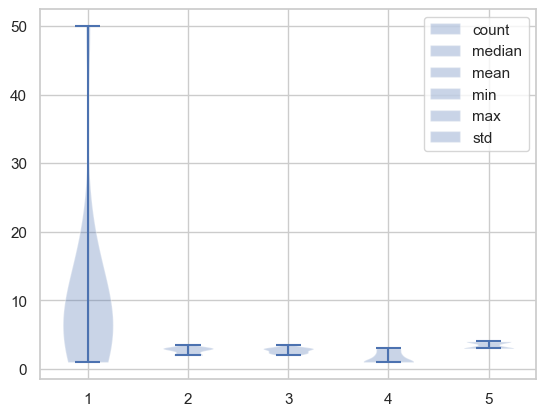

In [37]:
plt.violinplot(q2_classifications_by_user_summary)
plt.legend(labels=q2_classifications_by_user_summary.columns)
plt.show()

In [46]:
q2_classifications_by_user_summary

,mean
user_id,
2855607.0,2.857143
2863462.0,3.000000
2864613.0,2.000000
2868207.0,2.333333
2871772.0,2.250000
2871905.0,2.300000
2872047.0,2.416667
2872077.0,2.600000
2872141.0,3.000000


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


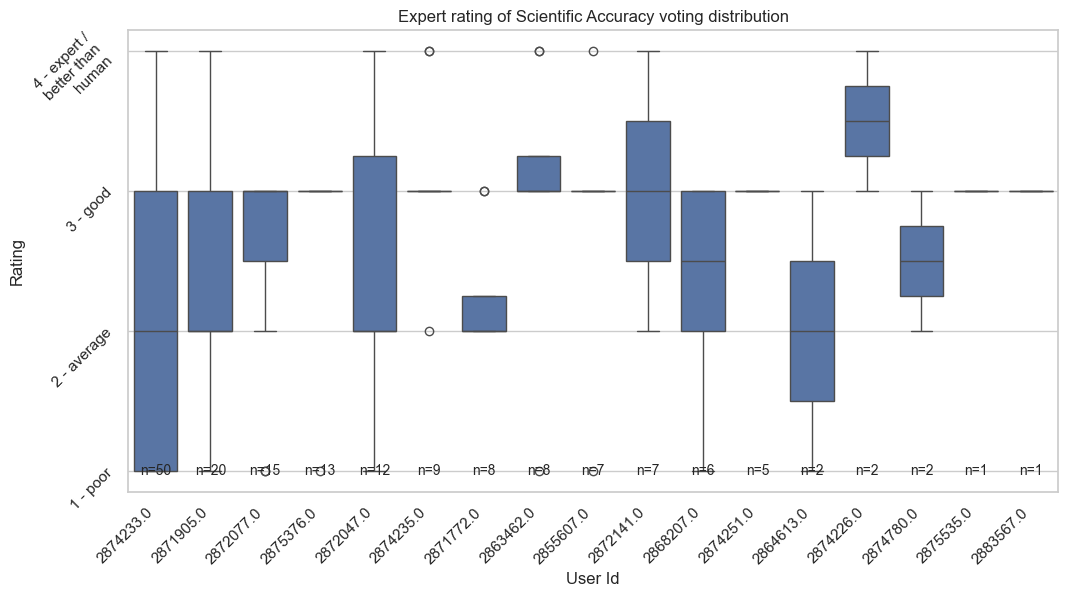

In [52]:
plt.figure(figsize=(12, 6))

colors = sns.color_palette("light:#5A9", as_cmap=True)

plt.title('Expert rating of Scientific Accuracy voting distribution')
plt.xlabel('User Id')
plt.ylabel('Rating')
plt.yticks(list(rating_description_to_number.values()), list(rating_description_to_number.keys()))

ax = sns.boxplot(x='user_id', y='T2_score', data=classifications_with_username, order=list(count_q2_answers_by_user_df.index))

# Add number of data points to each bar
for i, user_id in enumerate(count_q2_answers_by_user_df.index):
    count = count_q2_answers_by_user_df[user_id]
    ax.text(i, ax.get_ylim()[0] + 0.1, f'n={count}', ha='center', va='bottom', fontsize=10)

# Rotate x-tick labels and adjust alignment
plt.xticks(rotation=45, ha='right')
wrap_labels(plt.gca(), width=15)
plt.show()